In [1]:
import os
import logging, timeit
#from btEngine2.DataLoader import DataLoader
from btEngine2.MarketData import MarketData
from btEngine2.TradingRule import TradingRule

import platform
import pandas as pd

pd.options.display.float_format = lambda x: f'{x:,.0f}' if abs(x) >= 1000 else (f'{x:.2f}' if abs(x) < 10 else f'{x:.1f}')
# Detect operating system
if platform.system() == "Windows":
    ticker_csv_path = r'G:\Projects\BackTesting1.0\Data\Inputs\TickerList-Futs.csv'
    save_directory = r"G:\Projects\BackTesting1.0\Data\Bloomberg\Futures"
    helper_directory = r'G:\Projects\BackTesting1.0\Data\Bloomberg\HelperFiles'
    bt_folder = r'BackTests\mr_rsi_resrch'
    av_folder = r'G:\Projects\BackTesting1.0\Data\Inputs\AssetSizing-Futs.csv'
else:  # Assume macOS for other cases
    ticker_csv_path = r'Data/Inputs/TickerList-Futs.csv'
    save_directory = r"Data/Bloomberg/Futures"
    helper_directory = r'Data/Bloomberg/HelperFiles'
    bt_folder = r'BackTests/mr_rsi_resrch'
    av_folder = r'Data/Inputs/AssetSizing-Futs.csv'

# Define paths to auxiliary data for MarketData
tick_values_path = os.path.join(helper_directory, 'fut_val_pt.parquet')
fx_rates_path = os.path.join(helper_directory, 'fxHist.parquet')

# Initialize the MarketData
market_data = MarketData(
    base_directory=save_directory,
    tick_values_path=tick_values_path,
    fx_rates_path=fx_rates_path,
    instrument_type="Futures",
    n_threads=8,  # Number of threads for parallel data loading
    log_level=logging.ERROR  # Set to DEBUG for more detailed logs
)


In [2]:
tick = 'ZVL1 Index'
# Access data for a specific ticker
try:
    test_df = market_data.get_ticker_data(tick)
    print(test_df)
except ValueError as e:
    print(e)

# Access all preprocessed data
all_data = market_data.get_data()
print(f"Total tickers loaded: {len(all_data)}")

# Access FX rates
fx_rates = market_data.get_fx_rates()
# Access tick values
tick_values = market_data.get_tick_values()
# Access asset classes
asset_classes = market_data.get_asset_classes()

#market_data = market_data.date_filter(start_date='01012010')

shape: (2_884, 14)
┌────────────┬────────┬────────┬────────┬───┬─────────┬─────────┬─────────────────┬────────────────┐
│ Date       ┆ Open   ┆ High   ┆ Low    ┆ … ┆ BadOHLC ┆ FX_Rate ┆ Tick_Value_Base ┆ Tick_Value_USD │
│ ---        ┆ ---    ┆ ---    ┆ ---    ┆   ┆ ---     ┆ ---     ┆ ---             ┆ ---            │
│ date       ┆ f64    ┆ f64    ┆ f64    ┆   ┆ bool    ┆ f64     ┆ f64             ┆ f64            │
╞════════════╪════════╪════════╪════════╪═══╪═════════╪═════════╪═════════════════╪════════════════╡
│ 2013-07-02 ┆ 610.9  ┆ 610.9  ┆ 610.9  ┆ … ┆ true    ┆ 1.0     ┆ 100.0           ┆ 100.0          │
│ 2013-07-03 ┆ 600.9  ┆ 600.9  ┆ 600.9  ┆ … ┆ true    ┆ 1.0     ┆ 100.0           ┆ 100.0          │
│ 2013-07-04 ┆ 605.9  ┆ 605.9  ┆ 605.9  ┆ … ┆ true    ┆ 1.0     ┆ 100.0           ┆ 100.0          │
│ 2013-07-05 ┆ 606.9  ┆ 606.9  ┆ 606.9  ┆ … ┆ true    ┆ 1.0     ┆ 100.0           ┆ 100.0          │
│ 2013-07-08 ┆ 599.9  ┆ 599.9  ┆ 599.9  ┆ … ┆ true    ┆ 1.0     ┆ 100.0 

In [3]:
import pandas as pd
import numpy as np
import polars as pl

def compute_rsi(series: pd.Series, period: int) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def compute_slope(series: pd.Series, period: int) -> pd.Series:
    """
    Computes the slope of a rolling window over the series.
    """
    slopes = [np.nan] * (period - 1)
    for i in range(period - 1, len(series)):
        y = series.iloc[i - period + 1:i + 1]
        x = np.arange(period)
        # Perform linear regression to get the slope
        slope, intercept = np.polyfit(x, y, 1)
        slopes.append(slope)
    return pd.Series(slopes, index=series.index)

def generate_slope_diff_signal(
    df: pd.DataFrame,
    rsi_period: int,
    slope_period: int,
    rsi_overbought: float = 70,
    rsi_oversold: float = 30,
    smooth: tuple = ('ema', 5),
    trend_filter: tuple = ('ema', 20),
    lag_signal: int = 5
) -> pd.DataFrame:
    """
    Computes the continuous signal as the difference between price net change and RSI net change.

    Parameters:
    - df: DataFrame with at least a 'Close' column.
    - rsi_period: The period over which to calculate the RSI.
    - slope_period: The number of periods over which to calculate the net change.
    - rsi_overbought: RSI threshold for overbought condition.
    - rsi_oversold: RSI threshold for oversold condition.

    Returns:
    - DataFrame with additional columns: 'RSI', 'Price_Change', 'RSI_Change', 'Signal', 'Overbought', 'Oversold'.
    """
    if isinstance(df, pl.DataFrame):
        df = df.to_pandas()
    df = df.copy()

    # Compute RSI
    df['RSI'] = compute_rsi(df['Close'], rsi_period)

    # Compute Price Net Change
    df['Price_Change'] = compute_slope(df['Close'], slope_period)

    # Compute RSI Net Change
    df['RSI_Change'] = compute_slope(df['RSI'], slope_period)

    # Compute the Signal as the difference between Price Change and RSI Change

    # bearish divergence when price is rising and RSI is falling
    # bullish divergence when price is falling and RSI is rising
    df['Bearish Div'] = (df['Price_Change'] > 0) & (df['RSI_Change'] < 0) & (df['RSI'] > rsi_overbought)
    df['Bullish Div'] = (df['Price_Change'] < 0) & (df['RSI_Change'] > 0) & (df['RSI'] < rsi_oversold)

    # Bearish signal is difference between price and rsi change when bearish divergence
    df['Bearish Signal'] = np.where(df['Bearish Div'], -(df['Price_Change'] - df['RSI_Change']), 0)
    # Bullish signal is difference between price and rsi change when bullish divergence
    df['Bullish Signal'] = np.where(df['Bullish Div'], -(df['Price_Change'] - df['RSI_Change']), 0)

    # apply trend filter, bullish trend if close > ema, and bearish trend if close < ema
    if trend_filter[0] == 'ema':
        df['Trend Filter'] = np.where(df['Close'] > df['Close'].ewm(span=trend_filter[1]).mean(), 1, -1)
        df['Bearish Signal'] = np.where(df['Trend Filter'] == 1, 0, df['Bearish Signal'])
        df['Bullish Signal'] = np.where(df['Trend Filter'] == -1, 0, df['Bullish Signal'])
    elif trend_filter[0] == 'sma':
        df['Trend Filter'] = np.where(df['Close'] > df['Close'].rolling(window=trend_filter[1]).mean(), 1, -1)
        df['Bearish Signal'] = np.where(df['Trend Filter'] == 1, 0, df['Bearish Signal'])
        df['Bullish Signal'] = np.where(df['Trend Filter'] == -1, 0, df['Bullish Signal'])

    df['Bearish Signal'] = df['Bearish Signal'].shift(lag_signal)
    df['Bullish Signal'] = df['Bullish Signal'].shift(lag_signal)

    # Smooth the Signal
    if smooth[0] == 'ema':
        df['Bearish Signal'] = df['Bearish Signal'].ewm(span=smooth[1]).mean()
        df['Bullish Signal'] = df['Bullish Signal'].ewm(span=smooth[1]).mean()
    elif smooth[0] == 'sma':
        df['Bearish Signal'] = df['Bearish Signal'].rolling(window=smooth[1]).mean()
        df['Bullish Signal'] = df['Bullish Signal'].rolling(window=smooth[1]).mean()
        



    df.set_index('Date', inplace=True)

    return df

In [4]:
# Assuming df is your DataFrame with price data and a 'Close' column

# Parameters
rsi_period = 14  # N in your description
slope_period = 14  # X in your description
rsi_overbought = 60
rsi_oversold = 40

ticker = 'Z 1 Index'
df = market_data.get_ticker_data(ticker)[-700:]

# Generate the signal
df_with_signal = generate_slope_diff_signal(
    df,
    rsi_period,
    slope_period,
    rsi_overbought,
    rsi_oversold,
    smooth=('sma', 8),
    trend_filter=('sma', 8),
    lag_signal=1
)

# Now, you can filter based on RSI thresholds
# For example, when RSI > overbought threshold
overbought_df = df_with_signal[df_with_signal['Bearish Div']]

# When RSI < oversold threshold
oversold_df = df_with_signal[df_with_signal['Bullish Div']]

<Axes: >

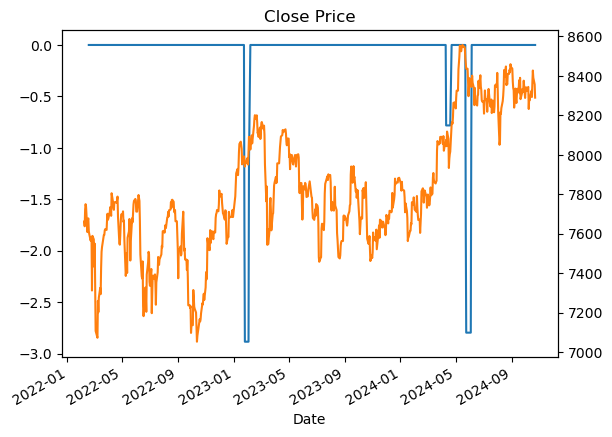

In [5]:
df_with_signal['Bearish Signal'].plot(title='Signal')
df_with_signal['Close'].plot(secondary_y=True, title='Close Price')

<Axes: >

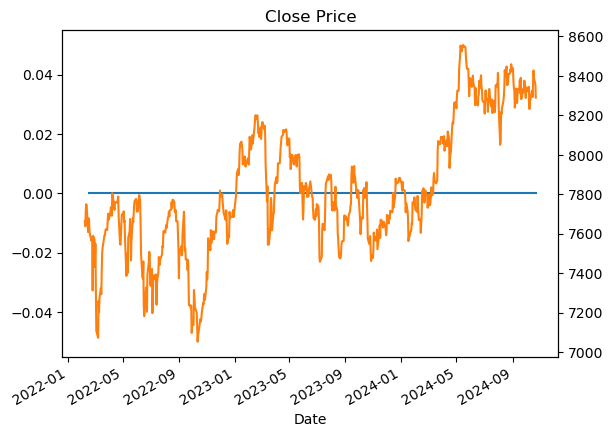

In [6]:
df_with_signal['Bullish Signal'].plot(title='Signal')
df_with_signal['Close'].plot(secondary_y=True, title='Close Price')

In [7]:
def generate_angle_signal(
    df: pd.DataFrame,
    rsi_period: int,
    slope_period: int,
    rsi_overbought: float = 60,
    rsi_oversold: float = 40,
    smooth: tuple = ('ema', 5),
    lag_signal: int = 0,
    min_angle: float = 0.0,
) -> pd.DataFrame:
    """
    Computes the angle between the price slope and RSI slope and generates signals based on divergence.

    Parameters:
    - df: DataFrame with at least a 'Close' column.
    - rsi_period: The period over which to calculate the RSI.
    - slope_period: The number of periods over which to calculate the slopes.
    - rsi_overbought: RSI threshold for overbought condition.
    - rsi_oversold: RSI threshold for oversold condition.
    - smooth: Tuple indicating smoothing method ('ema' or 'sma') and period.
    - trend_filter: Tuple indicating trend filter method ('ema' or 'sma') and period.
    - lag_signal: Number of periods to lag the signal.

    Returns:
    - DataFrame with additional columns including 'Angle', 'Bullish Signal', 'Bearish Signal'.
    """
    if isinstance(df, pl.DataFrame):
        df = df.to_pandas()
    df = df.copy()

    # Compute RSI
    df['RSI'] = compute_rsi(df['Close'], rsi_period)

    if smooth[0] == 'ema':
        df['RSI'] = df['RSI'].ewm(span=smooth[1]).mean()
    elif smooth[0] == 'sma':
        df['RSI'] = df['RSI'].rolling(window=smooth[1]).mean()
    
    # Compute Price Slope
    df['Price_Slope'] = compute_slope(df['Close'], slope_period)

    # Compute RSI Slope
    df['RSI_Slope'] = compute_slope(df['RSI'], slope_period)

    # Compute Angle between Price Slope and RSI Slope
    # Handle division by zero and invalid values
    with np.errstate(divide='ignore', invalid='ignore'):
        numerator = df['RSI_Slope'] - df['Price_Slope']
        denominator = 1 + (df['Price_Slope'] * df['RSI_Slope'])
        angle_rad = np.arctan(np.abs(numerator / denominator))
        angle_deg = np.degrees(angle_rad)
        df['Angle'] = angle_deg
    

    # Conditions for Bearish and Bullish Divergence
    df['Bearish Div'] = (df['Price_Slope'] > 0) & (df['RSI_Slope'] < 0) & (df['RSI'] > rsi_overbought) & (df['Angle'] > min_angle)
    df['Bullish Div'] = (df['Price_Slope'] < 0) & (df['RSI_Slope'] > 0) & (df['RSI'] < rsi_oversold) & (df['Angle'] > min_angle)

    # Bearish Signal: Use Angle as Signal Strength
    df['Bearish Signal'] = np.where(df['Bearish Div'], -df['Angle'], 0)
    # Bullish Signal: Use Angle as Signal Strength
    df['Bullish Signal'] = np.where(df['Bullish Div'], df['Angle'], 0)

    # Lag the Signals if needed
    if lag_signal > 0:
        df['Bearish Signal'] = df['Bearish Signal'].shift(lag_signal)
        df['Bullish Signal'] = df['Bullish Signal'].shift(lag_signal)

    # Smooth the Signals
    if smooth[0] == 'ema':
        df['Bearish Signal'] = df['Bearish Signal'].ewm(span=smooth[1]).mean()
        df['Bullish Signal'] = df['Bullish Signal'].ewm(span=smooth[1]).mean()
    elif smooth[0] == 'sma':
        df['Bearish Signal'] = df['Bearish Signal'].rolling(window=smooth[1]).mean()
        df['Bullish Signal'] = df['Bullish Signal'].rolling(window=smooth[1]).mean()

    df.set_index('Date', inplace=True)

    return df

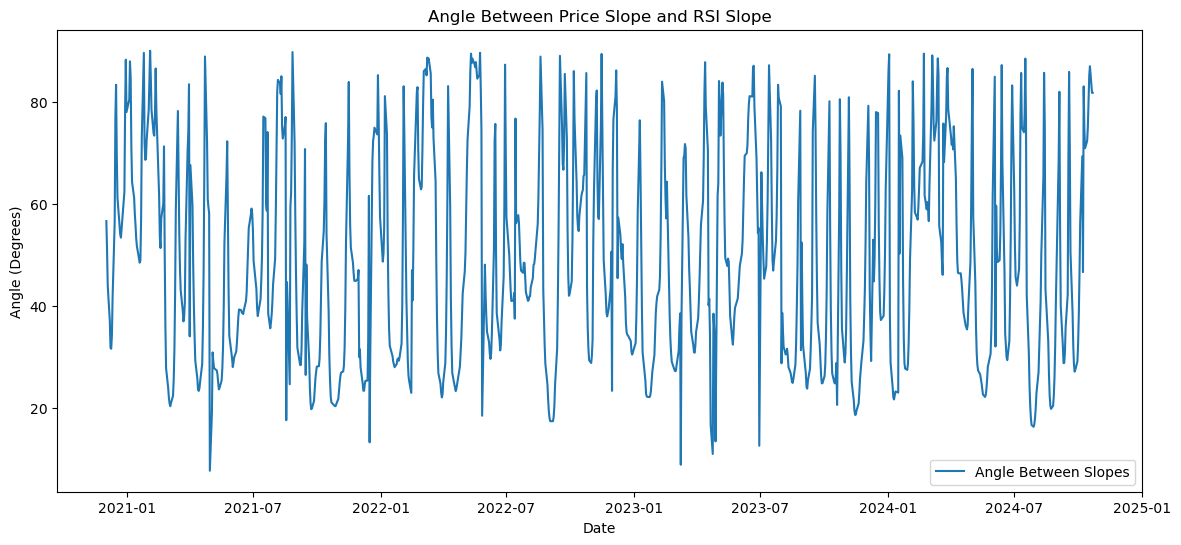

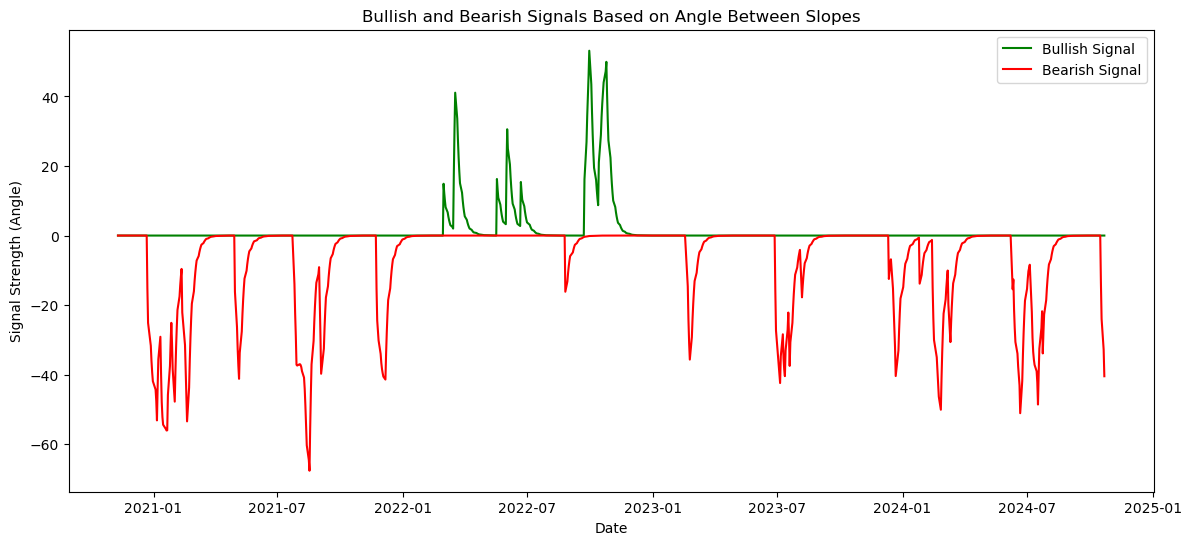

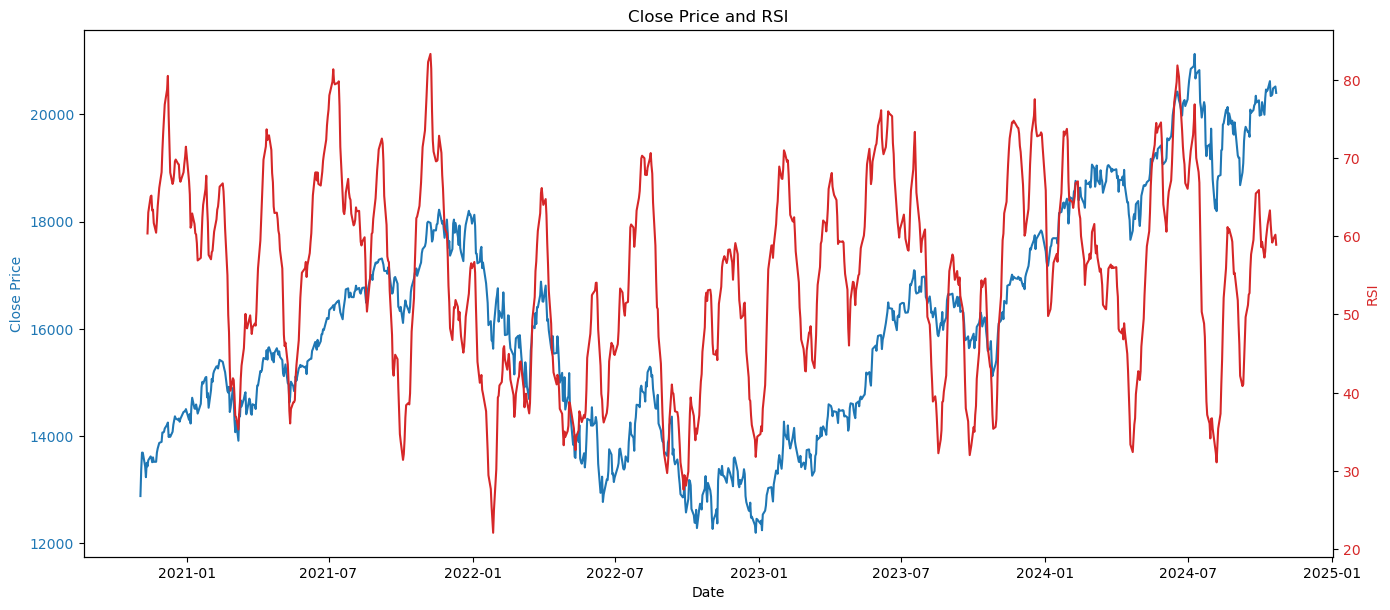

In [8]:
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with price data and columns 'Date' and 'Close'

# Parameters
rsi_period = 7     # N in your description
slope_period = 14         # X in your description
rsi_overbought = 60
rsi_oversold = 40
smooth = ('ema', 10)      # Smoothing method and period
lag_signal = 5           # No lag


ticker = 'NQ1 Index'
df = market_data.get_ticker_data(ticker)[-1000:]

# Generate the signal
df_with_angle_signal = generate_angle_signal(
    df,
    rsi_period,
    slope_period,
    rsi_overbought,
    rsi_oversold,
    smooth,
    lag_signal
)

# Now you can use 'Bullish Signal' and 'Bearish Signal' for your strategy

# Plot the Angle
plt.figure(figsize=(14, 6))
plt.plot(df_with_angle_signal.index, df_with_angle_signal['Angle'], label='Angle Between Slopes')
plt.title('Angle Between Price Slope and RSI Slope')
plt.xlabel('Date')
plt.ylabel('Angle (Degrees)')
plt.legend()
plt.show()

# Plot the Signals
plt.figure(figsize=(14, 6))
plt.plot(df_with_angle_signal.index, df_with_angle_signal['Bullish Signal'], label='Bullish Signal', color='green')
plt.plot(df_with_angle_signal.index, df_with_angle_signal['Bearish Signal'], label='Bearish Signal', color='red')
plt.title('Bullish and Bearish Signals Based on Angle Between Slopes')
plt.xlabel('Date')
plt.ylabel('Signal Strength (Angle)')
plt.legend()
plt.show()


# Plot the Close Price on the primary y-axis and RSI on the secondary y-axis
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price', color=color)
ax1.plot(df_with_angle_signal.index, df_with_angle_signal['Close'], label='Close Price', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('RSI', color=color)  # we already handled the x-label with ax1
ax2.plot(df_with_angle_signal.index, df_with_angle_signal['RSI'], label='RSI', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Close Price and RSI')
plt.show()

<Axes: >

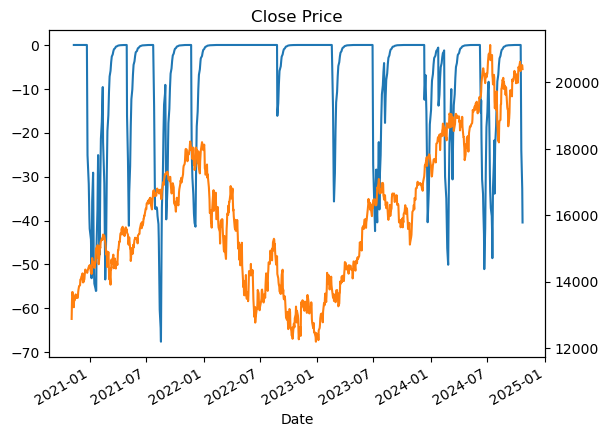

In [9]:
df_with_angle_signal['Bearish Signal'].plot(title='Signal')
df_with_angle_signal['Close'].plot(secondary_y=True, title='Close Price')

<Axes: >

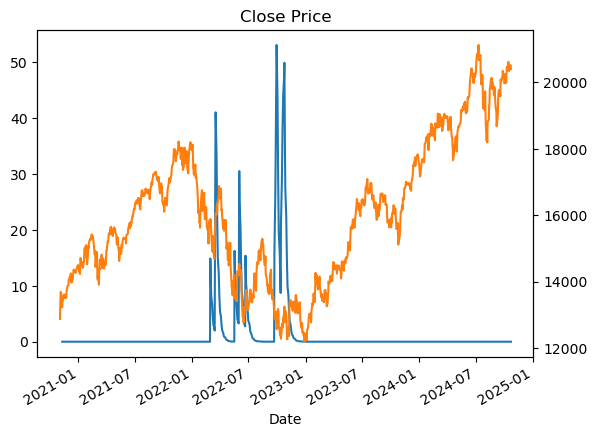

In [10]:
df_with_angle_signal['Bullish Signal'].plot(title='Signal')
df_with_angle_signal['Close'].plot(secondary_y=True, title='Close Price')

In [11]:
from btEngine2.Rules.MeanReversion.rsi_div_angle import *

In [12]:

ang_long_settings = dict(
    rsi_period=14,
    slope_period=28,
    rsi_overbought=65,
    rsi_oversold=35,
    smooth=('ema', 10),
    lag_signal=7,
    min_angle=25.0,
    max_hold_days=10,
    min_days_in_trade=3,
    early_exit=True,
    lmt_order=False,
    atr_period=5,
    atr_multiplier=1.0,
    entry_at='Open'
)



pSizeParams = {
    'AssetVol': av_folder,  # Target asset volatility in USD
    'VolLookBack': (30, 360, 0.3),
    'VolMethod': 'ewm'  # Lookback period for volatility calculation
}



In [13]:
filter_assts = []

angdiv_l = TradingRule(
    market_data=market_data,
    trading_rule_function=ang_div_long,
    trading_params=ang_long_settings,
    position_sizing_params=pSizeParams,  # Define as needed
    incl_assets=filter_assts,  # Include all involved assets
    name_label='rsidiv_angle',
    strat_descr= f'rsi angle divergence mr long strategy',
    log_level=logging.ERROR,
    bt_folder = bt_folder
)

filter_assts = []


angdiv_s = TradingRule(
    market_data=market_data,
    trading_rule_function=ang_div_short,
    trading_params=ang_long_settings,
    position_sizing_params=pSizeParams,  # Define as needed
    incl_assets=filter_assts,  # Include all involved assets
    name_label='rsidiv_angle',
    strat_descr= f'rsi angle divergence mr long strategy',
    log_level=logging.ERROR,
    bt_folder = bt_folder
)


/Users/utkarsh/Documents/Projects/system/systr/btEngine2/Rules/MeanReversion/rsi_div_angle.py:248: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_signals['TradeEntry'].iloc[entry_idx] = df_pd[entry_at].iloc[entry_idx]
/Users/utkarsh/Docume

,Date,Open,High,Low,Close,Volume,Name,Descr,Carry_Close,Carry,...,USD_PnL_1lot,RollingStdDev,AnnualizedVol_1lot,USD_Notional,20d_Price_Vol,PositionPnL_USD,Strategy_PnL_USD,Strategy_Equity_USD,Num_Lots,Trade_ID
1,1999-06-22,"4,598","4,616","4,544","4,549","4,430",NQ1 Index,NASDAQ 100 E-MINI,NaN,NaN,...,NaN,NaN,NaN,NaN,34.5,NaN,NaN,NaN,0.00,
2,1999-06-23,"4,546","4,571","4,522","4,566","4,625",NQ1 Index,NASDAQ 100 E-MINI,"4,127",NaN,...,330.0,NaN,NaN,0.00,34.5,0.00,0.00,0.00,0.00,
3,1999-06-24,"4,566","4,570","4,515","4,524","4,395",NQ1 Index,NASDAQ 100 E-MINI,"4,086",NaN,...,-820.0,813.2,"12,909",0.00,34.5,-0.00,-0.00,0.00,0.00,
4,1999-06-25,"4,522","4,559","4,500","4,522","2,751",NQ1 Index,NASDAQ 100 E-MINI,"4,083",NaN,...,-60.0,582.3,"9,244",0.00,34.5,"-6,960",-0.00,0.00,0.00,
5,1999-06-28,"4,530","4,574","4,520","4,570","4,239",NQ1 Index,NASDAQ 100 E-MINI,"4,132",NaN,...,970.0,752.1,"11,939",0.00,34.5,"157,140",0.00,0.00,0.00,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6439,2024-10-16,"20,334","20,398","20,206","20,350","417,571",NQ1 Index,NASDAQ 100 E-MINI,"20,574",-887.8,...,150.0,"4,196","66,616",0.00,195.0,"3,300",0.00,"104,700",0.00,
6440,2024-10-17,"20,328","20,595","20,277","20,368","535,486",NQ1 Index,NASDAQ 100 E-MINI,"20,596",-893.6,...,370.0,"4,147","65,832",0.00,192.8,"8,510",0.00,"104,700",0.00,
6441,2024-10-18,"20,384","20,530","20,321","20,484","385,566",NQ1 Index,NASDAQ 100 E-MINI,"20,713",-899.6,...,"2,310","4,110","65,242",0.00,158.0,"53,130",0.00,"104,700",0.00,
6442,2024-10-21,"20,496","20,554","20,344","20,520","456,078",NQ1 Index,NASDAQ 100 E-MINI,"20,749",-903.6,...,720.0,"4,063","64,500",0.00,158.6,"16,560",0.00,"104,700",0.00,


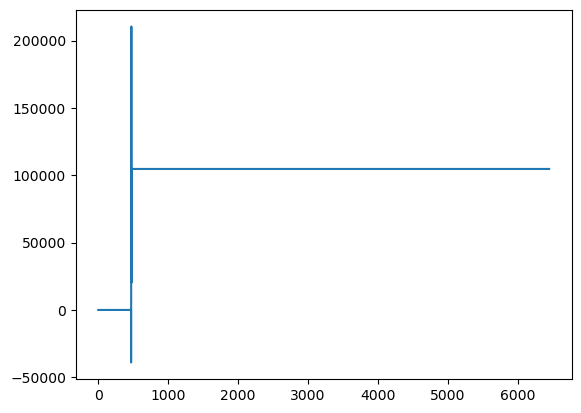

In [14]:
test = angdiv_l.backtest_asset('NQ1 Index')
test['Strategy_Equity_USD'].plot()
test

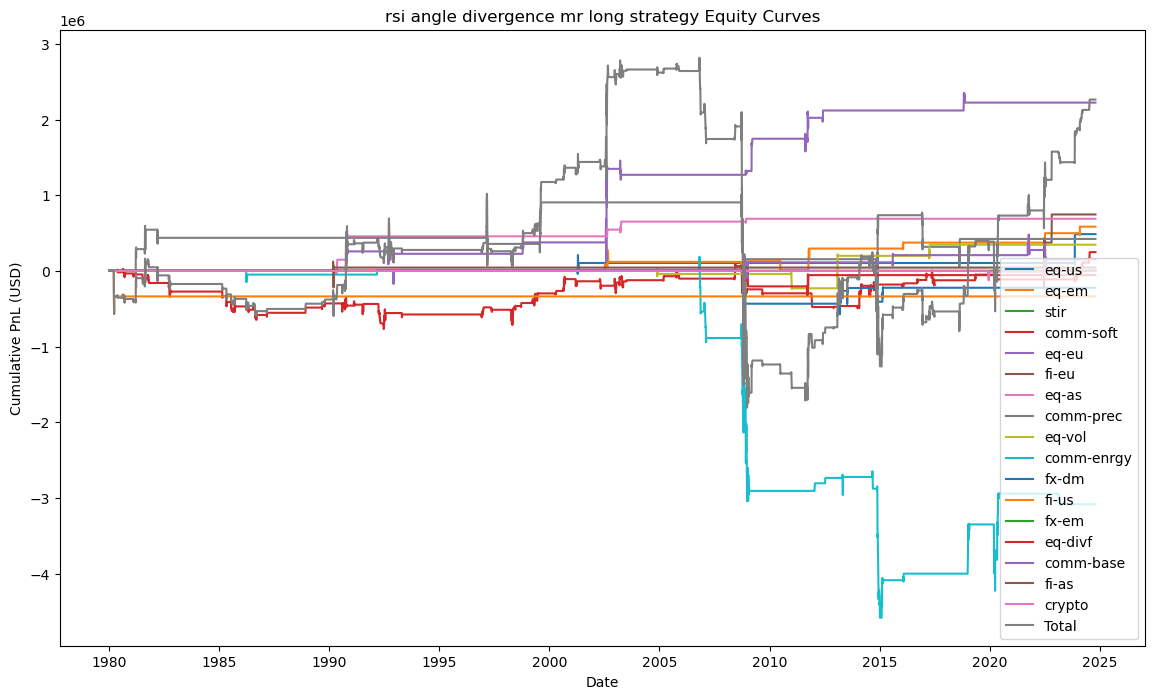

In [15]:
equity = angdiv_l.plot_equity(byac=True, totalsys=True)

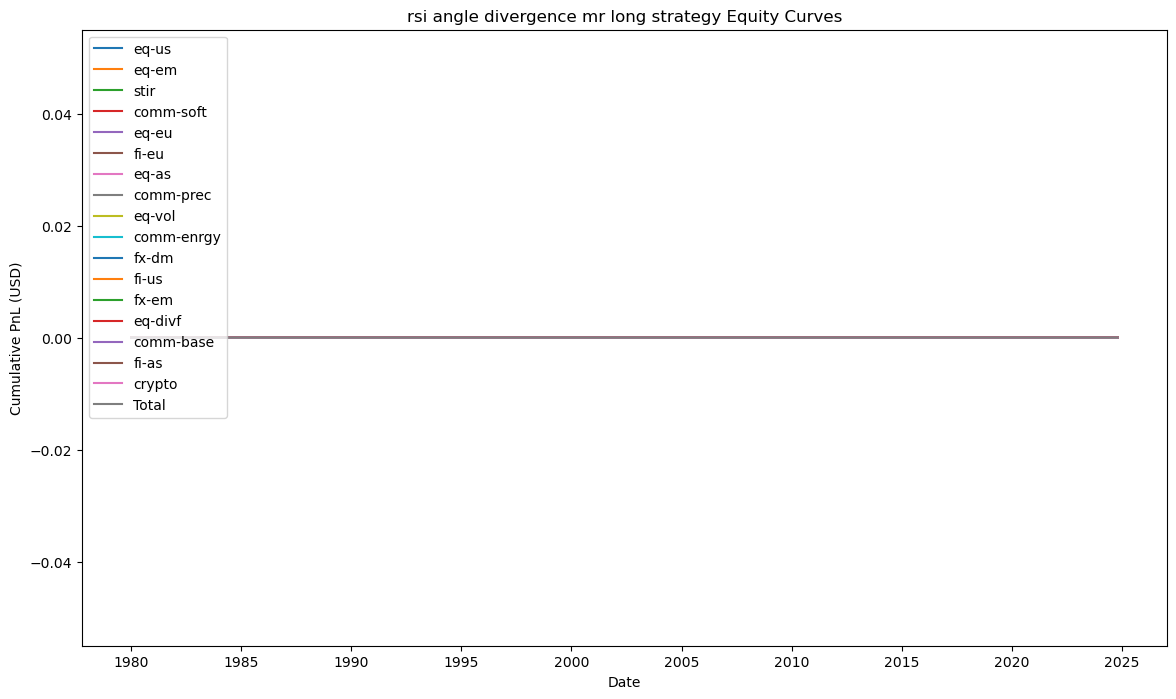

In [16]:
equity2 = angdiv_s.plot_equity(byac=True, totalsys=True)